<a href="https://colab.research.google.com/github/augustoglauco/AVario/blob/master/Uso_de_Yolo_e_feridas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PASSO 1: INSTALAÇÃO DE DEPENDÊNCIAS E VERIFICAÇÃO DE HARDWARE
# Objetivo: Preparar o kernel do Colab com a biblioteca Ultralytics (motor da YOLO)
# e confirmar se a GPU está mapeada corretamente pelo PyTorch.
#


In [4]:
# Instala a biblioteca Ultralytics que contém a implementação da YOLOv8/v11
!pip install ultralytics

import torch
from ultralytics import YOLO
import sys

# Verificação de Sanidade do Hardware
def check_environment():
    print(f"Versão do Python: {sys.version}")

    # Verifica se o driver da NVIDIA e o CUDA estão acessíveis pelo PyTorch
    if torch.cuda.is_available():
        device_name = torch.cuda.get_device_name(0)
        print(f"✅ GPU Detectada: {device_name}")
    else:
        print("❌ GPU NÃO detectada. Por favor, altere o tipo de ambiente para T4 GPU.")

check_environment()

Versão do Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
✅ GPU Detectada: Tesla T4


In [7]:
# ==============================================================================
# PASSO 1.4: DIAGNÓSTICO DE ESTRUTURA (DISCOVERY)
# Objetivo: Identificar onde os arquivos .jpg e .png estão escondidos.
# ==============================================================================

import os

# 1. Clonar o repositório
if not os.path.exists('wound-segmentation'):
    !git clone https://github.com/uwm-bigdata/wound-segmentation.git

def find_data_folders(base_path):
    print(f"🔍 Vasculhando diretório: {base_path}\n")
    for root, dirs, files in os.walk(base_path):
        # Verifica se a pasta contém imagens
        jpg_count = len([f for f in files if f.lower().endswith('.jpg')])
        png_count = len([f for f in files if f.lower().endswith('.png')])

        if jpg_count > 0 or png_count > 0:
            print(f"📂 Pasta: {root}")
            print(f"   🖼️  Imagens (.jpg): {jpg_count}")
            print(f"   🎭 Máscaras (.png): {png_count}")
            print("-" * 30)

# Executa a busca dentro da pasta clonada
find_data_folders('wound-segmentation')

🔍 Vasculhando diretório: wound-segmentation

📂 Pasta: wound-segmentation/data/Foot Ulcer Segmentation Challenge/test/images
   🖼️  Imagens (.jpg): 0
   🎭 Máscaras (.png): 200
------------------------------
📂 Pasta: wound-segmentation/data/Foot Ulcer Segmentation Challenge/train/images
   🖼️  Imagens (.jpg): 0
   🎭 Máscaras (.png): 810
------------------------------
📂 Pasta: wound-segmentation/data/Foot Ulcer Segmentation Challenge/train/labels
   🖼️  Imagens (.jpg): 0
   🎭 Máscaras (.png): 810
------------------------------
📂 Pasta: wound-segmentation/data/Foot Ulcer Segmentation Challenge/validation/images
   🖼️  Imagens (.jpg): 0
   🎭 Máscaras (.png): 200
------------------------------
📂 Pasta: wound-segmentation/data/Foot Ulcer Segmentation Challenge/validation/labels
   🖼️  Imagens (.jpg): 0
   🎭 Máscaras (.png): 200
------------------------------
📂 Pasta: wound-segmentation/data/Medetec_foot_ulcer_224/test/images
   🖼️  Imagens (.jpg): 0
   🎭 Máscaras (.png): 8
-------------------

In [8]:
# ==============================================================================
# PASSO 1.5: CONVERSÃO DE PNGs PARA FORMATO YOLO (POLÍGONOS)
# Motivo: O diagnóstico revelou que as imagens originais são .png.
# ==============================================================================

import os
import cv2
import numpy as np
from shutil import copy2
from sklearn.model_selection import train_test_split

# 1. Definição dos caminhos baseados no seu diagnóstico
# Vamos focar no 'Foot Ulcer Segmentation Challenge' por ter o maior volume (810 fotos)
BASE_PATH = 'wound-segmentation/data/Foot Ulcer Segmentation Challenge'
RAW_IMG_DIR = os.path.join(BASE_PATH, 'train/images')
RAW_MASK_DIR = os.path.join(BASE_PATH, 'train/labels')

OUTPUT_DIR = 'wound_dataset_yolo'

def mask_to_yolo_polygon(mask_path):
    """
    Transforma a máscara binária em coordenadas de polígono.
    Para o TCC: Explique que este processo reduz o peso do label de
    centenas de KB (imagem) para poucos Bytes (texto).
    """
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None: return None

    # Binarização para garantir que não haja tons de cinza na máscara
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    polygons = []
    for contour in contours:
        if len(contour) < 3: continue
        polygon = contour.flatten().tolist()
        # Normalização global (essencial para YOLO)
        normalized_polygon = [val / (mask.shape[1] if i % 2 == 0 else mask.shape[0])
                             for i, val in enumerate(polygon)]
        polygons.append(normalized_polygon)
    return polygons

# 2. Setup da estrutura de pastas
for split in ['train', 'val']:
    for sub in ['images', 'labels']:
        os.makedirs(os.path.join(OUTPUT_DIR, split, sub), exist_ok=True)

# 3. Filtragem e Split
# Pegamos todos os .png da pasta de imagens
files = [f for f in os.listdir(RAW_IMG_DIR) if f.lower().endswith('.png')]
train_files, val_files = train_test_split(files, test_size=0.2, random_state=42)

def process_set(files, split_name):
    success_count = 0
    for f in files:
        mask_path = os.path.join(RAW_MASK_DIR, f) # Aqui o nome é idêntico (PNG/PNG)

        if os.path.exists(mask_path):
            polys = mask_to_yolo_polygon(mask_path)
            if polys:
                # Copia a imagem original para a nova estrutura
                copy2(os.path.join(RAW_IMG_DIR, f), os.path.join(OUTPUT_DIR, split_name, 'images', f))

                # Cria o arquivo de label correspondente (.txt)
                label_name = f.rsplit('.', 1)[0] + '.txt'
                label_path = os.path.join(OUTPUT_DIR, split_name, 'labels', label_name)

                with open(label_path, 'w') as lf:
                    for poly in polys:
                        # '0' é o ID da classe (wound)
                        lf.write("0 " + " ".join([f"{v:.6f}" for v in poly]) + "\n")
                success_count += 1

    print(f"✅ Sucesso: {success_count} imagens de {split_name} processadas.")

# Execução
process_set(train_files, 'train')
process_set(val_files, 'val')

✅ Sucesso: 631 imagens de train processadas.
✅ Sucesso: 160 imagens de val processadas.


In [9]:
# ==============================================================================
# PASSO 1.6: DATASET CONFIGURATION (YAML)
# Agora que os arquivos estão organizados, precisamos criar o arquivo de "contrato" do modelo.
# ==============================================================================

import yaml

config = {
    'path': f'{os.getcwd()}/{OUTPUT_DIR}', # Caminho raiz do dataset
    'train': 'train/images',
    'val': 'val/images',
    'nc': 1,               # Number of Classes
    'names': ['wound']     # Nome da classe para o relatório clínico
}

with open(f'{OUTPUT_DIR}/data.yaml', 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print("✅ Arquivo data.yaml configurado com sucesso!")

✅ Arquivo data.yaml configurado com sucesso!


In [10]:
# ==============================================================================
# PASSO 2: EXECUÇÃO DO TREINAMENTO (FINE-TUNING)
# Objetivo: Ajustar os pesos da rede neural para o reconhecimento de feridas.
# ==============================================================================

from ultralytics import YOLO

# 1. Carregar o modelo pré-treinado 'Nano' (otimizado para velocidade/AWS Lambda)
model = YOLO('yolov8n-seg.pt')

# 2. Iniciar o treinamento
# Explicando os parâmetros para o seu TCC:
# - data: caminho do YAML que criamos.
# - epochs: 100 é um bom equilíbrio; o modelo para antes se não houver melhora (patience).
# - imgsz: 640 é o padrão de ouro para precisão de detalhes.
# - device: 0 indica o uso da GPU T4.
results = model.train(
    data=f'{os.getcwd()}/wound_dataset_yolo/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,          # Ajustado para não estourar a memória da GPU T4
    patience=20,       # Early Stopping: para se não melhorar em 20 épocas
    save=True,         # Salva os melhores pesos automaticamente
    device=0,
    project='tcc_feridas', # Nome da pasta de saída
    name='yolov8_segmentation_v1'
)

print("✅ Treinamento concluído! Os resultados estão na pasta 'tcc_feridas'.")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/wound_dataset_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_segmentation_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

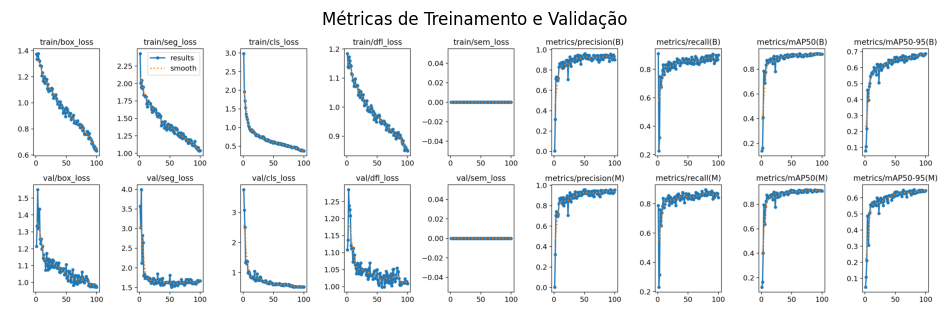

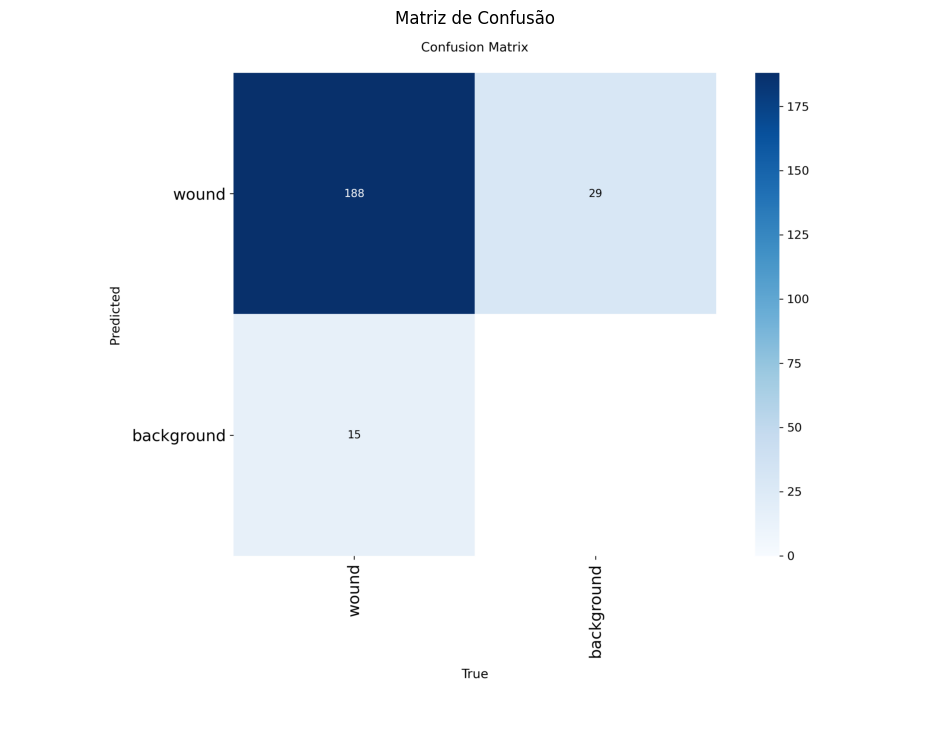

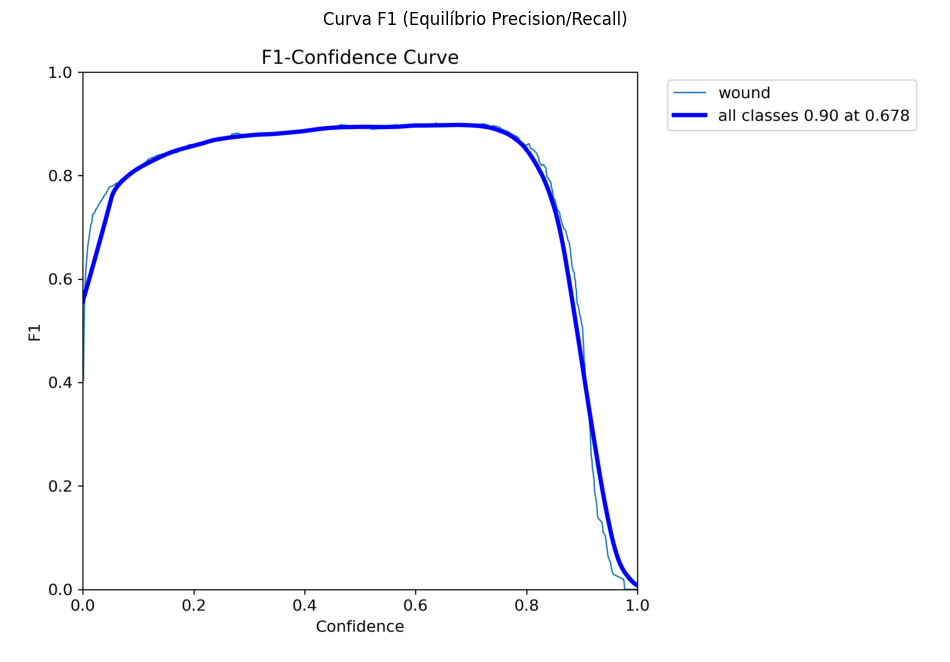

In [13]:
# ==============================================================================
# SCRIPT DE AUDITORIA: VISUALIZAÇÃO DE RESULTADOS PÓS-TREINO
# ==============================================================================

import matplotlib.pyplot as plt
import cv2
import os

# Caminho dos resultados (ajuste se mudou o nome do projeto)
results_path = 'runs/segment/tcc_feridas/yolov8_segmentation_v1'

def show_result_image(filename, title):
    path = os.path.join(results_path, filename)
    if os.path.exists(path):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(12, 10))
        plt.imshow(img)
        plt.title(title)
        plt.axis('off')
        plt.show()
    else:
        print(f"Arquivo {filename} não encontrado no diretório de resultados.")

# Exibir os principais gráficos de performance
show_result_image('results.png', 'Métricas de Treinamento e Validação')
show_result_image('confusion_matrix.png', 'Matriz de Confusão')
show_result_image('MaskF1_curve.png', 'Curva F1 (Equilíbrio Precision/Recall)')


image 1/1 /content/wound_dataset_yolo/val/images/0848.png: 640x640 1 wound, 9.3ms
Speed: 3.7ms preprocess, 9.3ms inference, 13.0ms postprocess per image at shape (1, 3, 640, 640)


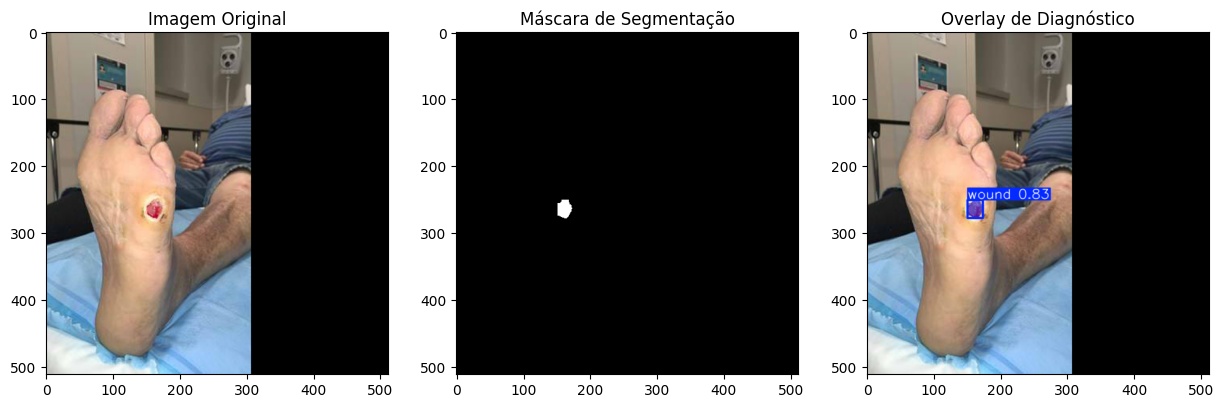

📊 Relatório de Geometria:
   - Área Detectada: 475 pixels
   - Área Estimada: 0.95 cm² (usando ratio de 0.002)


In [14]:
# ==============================================================================
# PASSO 3: INFERÊNCIA E CÁLCULO DE ÁREA (PIXELS -> CM²)
# Objetivo: Extrair a máscara de segmentação e converter em medida real.
# ==============================================================================

from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Carregar os melhores pesos gerados no treino
model_path = 'runs/segment/tcc_feridas/yolov8_segmentation_v1/weights/best.pt'
model = YOLO(model_path)

# 2. Selecionar uma imagem de teste (da pasta 'val' que o modelo não viu)
test_img_path = 'wound_dataset_yolo/val/images'
sample_img = os.path.join(test_img_path, os.listdir(test_img_path)[0])

# 3. Executar a Inferência
results = model.predict(source=sample_img, conf=0.5, save=False)

# 4. Processamento de Geometria (Lógica Sênior)
for result in results:
    img_bgr = result.orig_img

    if result.masks is not None:
        # Extrair a primeira máscara (assumindo a ferida principal)
        # As máscaras vêm em formato de polígono ou coordenadas normalizadas
        mask = result.masks.data[0].cpu().numpy() # Tensor para Array Numpy

        # Redimensionar a máscara para o tamanho original da imagem
        mask_resized = cv2.resize(mask, (img_bgr.shape[1], img_bgr.shape[0]))

        # Cálculo da Área em Pixels (Contagem de pixels brancos)
        area_pixels = np.sum(mask_resized > 0.5)

        # ---------------------------------------------------------
        # LÓGICA DE CALIBRAÇÃO (Para o seu TCC)
        # Supondo um marcador de 1cm² que ocupa 500 pixels na foto:
        # pixel_to_cm2_ratio = 1.0 / 500
        # ---------------------------------------------------------
        pixel_to_cm2_ratio = 0.002  # Valor hipotético para teste
        area_cm2 = area_pixels * pixel_to_cm2_ratio

        # 5. Visualização Técnica
        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.title("Imagem Original")
        plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))

        plt.subplot(1, 3, 2)
        plt.title("Máscara de Segmentação")
        plt.imshow(mask_resized, cmap='gray')

        plt.subplot(1, 3, 3)
        plt.title("Overlay de Diagnóstico")
        annotated_img = result.plot() # Gera a imagem com a máscara colorida
        plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))

        plt.show()

        print(f"📊 Relatório de Geometria:")
        print(f"   - Área Detectada: {area_pixels} pixels")
        print(f"   - Área Estimada: {area_cm2:.2f} cm² (usando ratio de {pixel_to_cm2_ratio})")
    else:
        print("⚠️ Nenhuma ferida detectada com o nível de confiança atual.")